In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [ ]:
import sys
print(sys.executable)

/opt/anaconda3/envs/walws25-26/bin/python


In [ ]:
# plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决macOS字体warning问题

plt.rcParams['axes.unicode_minus'] = False
# 处理中文显示和负号显示问题

# 1. 读取数据并检验

## (1) 整理问卷数据 (数据准备)

从问卷中获得的原始变量包括 (input of ANCOVA)
- 睡眠质量 (PSQI 总分, intervall): 分数越高 → 睡眠质量越差; // 因变量 AV
  - 计算公式: PSQI总分 = β₀ + β₁×使用时间 + β₂×刺激强度 + β₃×年龄 + β₄×咖啡因 + β₅×压力 + ε 
    - β₀: intercept截距 = 当所有自变量都等于 0 时, PSQI 的“基准值”, 这时模型预测的 PSQI = β₀
    - β₁ = “影响系数”, Time 每增加 1 个单位, PSQI 会改变 β₁ 个单位 (统计模型假设的是“线性关系”)
- 睡前社交媒体使用内容 (<span style="color:red">kategorie or 刺激强度, intervall?</span>); <span style="color:red">// 自变量 / 因子 UV ???</span>
- 睡前社交媒体使用时间 (stunden/minuten/sekunden, intervall); <span style="color:red">// 协变量 CV ???</span>
- //额外协变量
  - 年龄（Intervall）
  - 性别（Kategorie → Dummy 编码）
  - 咖啡因摄入（Intervall 或 ordinal）
  - 压力水平（Intervall，如 PSS）

## (2) 数据清理
- 缺失值
  - PSQI 或 时间 缺失 → 删除个案
  - 控制变量缺失 → 可考虑均值替代（谨慎）
- 异常值（Outlier）
  - 使用 Boxplot / Z-Wert
  - 极端使用时间（例如每天 12h）→ 判断是否真实
- 编码检查
  - 内容类别是否正确
  - 性别是否 dummy 编码（0 / 1）

In [ ]:
warnings.filterwarnings('ignore')

csv_file = 'Soziale Medien und psychische Gesundheit.csv'

print("="*60)
print("数据加载与检查")
print("="*60)

if not os.path.exists(csv_file):
    raise FileNotFoundError(f"错误：找不到数据文件 '{csv_file}'。请确保文件存在。")

try:
    data = pd.read_csv(csv_file, encoding='utf-8-sig')
    print(f"\n✓ 数据已从 {csv_file} 成功加载")
except UnicodeDecodeError:
    try:
        data = pd.read_csv(csv_file, encoding='gbk')
        print(f"\n✓ 数据已从 {csv_file} 成功加载 (使用GBK编码)")
    except:
        data = pd.read_csv(csv_file, encoding='utf-8')
        print(f"\n✓ 数据已从 {csv_file} 成功加载 (使用UTF-8编码)")
except Exception as e:
    raise Exception(f"读取CSV文件时出错: {str(e)}")

print("\n" + "="*60)
print("数据验证")
print("="*60)

if data.empty:
    raise ValueError("错误：数据文件为空")

required_columns = ['age', 'gender', 'content_type', 'usage_time', 
                   'stim_intensity', 'caffeine', 'stress', 'PSQI_total']
missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"错误：缺少必需的列: {missing_columns}")

print(f"\n✓ 所有必需的列都存在")

print(f"\n数据类型:")
print(data.dtypes)

missing_values = data.isnull().sum()
if missing_values.sum() > 0:
    print(f"\n⚠ 警告：发现缺失值:")
    print(missing_values[missing_values > 0])
else:
    print(f"\n✓ 无缺失值")

print(f"\n数据范围检查:")
print(f"  年龄范围: {data['age'].min():.1f} - {data['age'].max():.1f}")
print(f"  使用时间范围: {data['usage_time'].min():.1f} - {data['usage_time'].max():.1f} 分钟")
print(f"  刺激强度范围: {data['stim_intensity'].min():.1f} - {data['stim_intensity'].max():.1f}")
print(f"  咖啡因范围: {data['caffeine'].min()} - {data['caffeine'].max()}")
print(f"  压力水平范围: {data['stress'].min():.1f} - {data['stress'].max():.1f}")
print(f"  PSQI总分范围: {data['PSQI_total'].min():.1f} - {data['PSQI_total'].max():.1f}")

print(f"\n分类变量检查:")
print(f"  性别: {data['gender'].unique()}")
print(f"  内容类型: {data['content_type'].unique()}")
print(f"  性别分布:")
print(data['gender'].value_counts())
print(f"  内容类型分布:")
print(data['content_type'].value_counts())

print("\n" + "="*60)
print("数据摘要")
print("="*60)
print(f"\n样本数量: {len(data)}")
print(f"数据形状: {data.shape}")
print(f"\n数据前5行:")
print(data.head())
print(f"\n数据统计摘要:")
print(data.describe())



数据加载与检查

✓ 数据已从 Soziale Medien und psychische Gesundheit.csv 成功加载

数据验证

✓ 所有必需的列都存在

数据类型:
时间戳记                                                                                object
By clicking the “I agree” button, I consent to participate in this study.           object
age                                                                                  int64
gender                                                                              object
Your living situation                                                               object
caffeine                                                                            object
stress                                                                               int64
During the current week, have you used sleep aids or aromatherapy?                  object
usage_time                                                                           int64
content_type                                                                        objec

## (3) 统计描述
- 使用时间的
  - 范围
  - 均值（M）
  - 标准差（SD）
- 不同内容组的
  - 组别
  - 样本量（n）
  - 刺激强度 PSQI 
    - 均值（M）
    - 标准差（SD）

## (4)* 探索性 / 前期分析 (Explorative Voranalysen)

- 1.基础相关性 

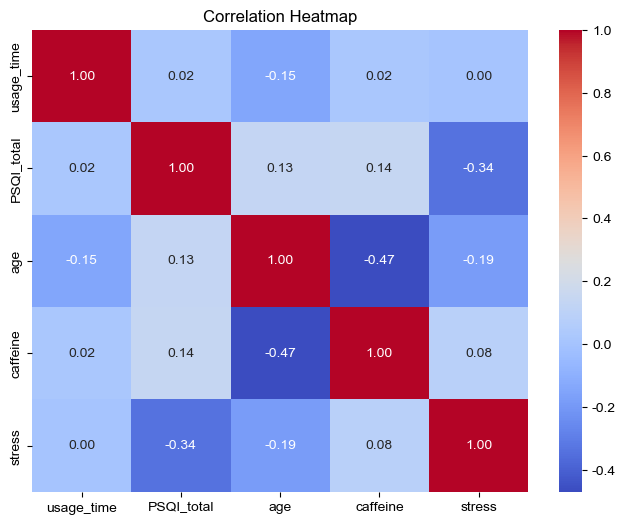

In [ ]:
numeric_vars = ['usage_time', 'PSQI_total', 'age', 'caffeine', 'stress']
# 对caffeine字段进行预处理
data['caffeine'] = data['caffeine'].replace({'1-2': 1.5, '3+': 3})

corr = data[numeric_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- 2.ANCOVA 模型（app分类）

In [ ]:
# 公式逻辑：
# PSQI ~ 时间(线性) + 内容(分类) + 时间*内容(交互) + 控制变量
formula = 'PSQI_total ~ usage_time * C(content_type) + age + caffeine + stress'

model = smf.ols(formula, data=data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             PSQI_total   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1.158
Date:                Sun, 22 Feb 2026   Prob (F-statistic):              0.411
Time:                        13:05:01   Log-Likelihood:                -72.007
No. Observations:                  21   AIC:                             166.0
Df Residuals:                      10   BIC:                             177.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

- 3.类型与刺激强度分组


刺激强度中位数: 6.0

App 类型与刺激分组的对应关系 (混淆矩阵):
Arousal_Group                   High Arousal  Low Arousal
content_type                                             
Games                                      1            0
Image/Video                                6            7
Reading/Audio                              1            0
Social media communication                 2            3
no social media before bedtime             0            1


<Figure size 1000x600 with 0 Axes>

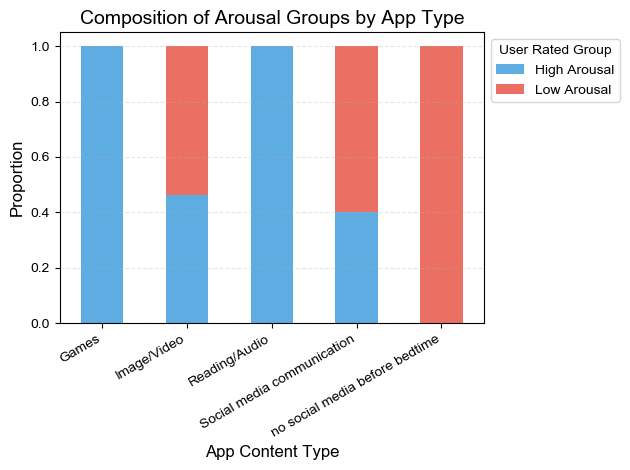

In [ ]:
median_intensity = data['stim_intensity'].median()
print(f"\n刺激强度中位数: {median_intensity}")

def get_arousal_group(score):
    if score > median_intensity:
        return 'High Arousal'
    else:
        return 'Low Arousal'

data['Arousal_Group'] = data['stim_intensity'].apply(get_arousal_group)

crosstab = pd.crosstab(data['content_type'], data['Arousal_Group'])
print("\nApp 类型与刺激分组的对应关系 (混淆矩阵):")
print(crosstab)

crosstab_norm = pd.crosstab(data['content_type'], data['Arousal_Group'], normalize='index')

plt.figure(figsize=(10, 6))
crosstab_norm.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], alpha=0.8)

plt.title('Composition of Arousal Groups by App Type', fontsize=14)
plt.xlabel('App Content Type', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.legend(title='User Rated Group', loc='upper left', bbox_to_anchor=(1, 1))
# plt.xticks(rotation=0)
plt.xticks(rotation=30, ha = 'right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. ANCOVA 前提条件检验

## (1) 回归斜率同质性 (Homogenität der Regressionssteigungen) 
- Motivation: ANCOVA 的核心假设是, 各内容组中, <span style="color:red">协变量（使用时间）→ 因变量（睡眠质量） 的关系是相同的</span>
  - 所以不同内容组的回归线必须是平行的
- How to do: 在模型中加入 "时间 × 内容" 交互项, 看 "交互项的 p 值"
  - p > .05 → ✅ 前提满足 → 可以做 ANCOVA
  - p < .05 → ❌ 不能用 ANCOVA → 要改用 多元回归 + 交互解释

### -- 交互结果图 --

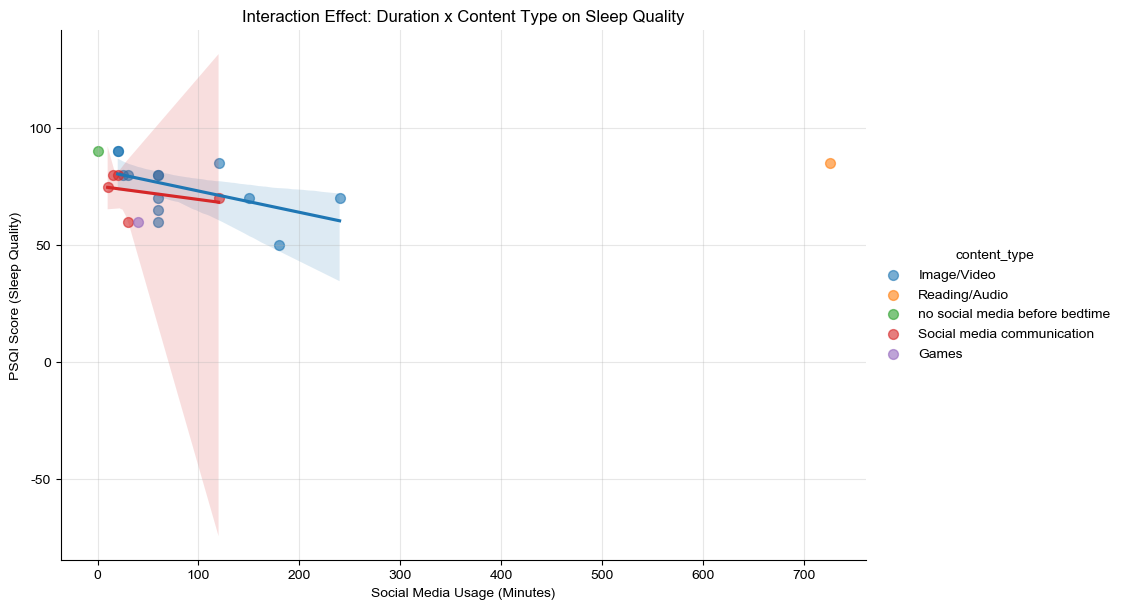

In [ ]:
g = sns.lmplot(
    data=data,
    x="usage_time", 
    y="PSQI_total", 
    hue="content_type",  # 根据内容分组画线
    height=6, 
    aspect=1.5,
    ci=95,               # 自动画 95% 置信区间
    scatter_kws={"s": 50, "alpha": 0.6}
)

plt.title("Interaction Effect: Duration x Content Type on Sleep Quality")
plt.xlabel("Social Media Usage (Minutes)")
plt.ylabel("PSQI Score (Sleep Quality)")
plt.grid(True, alpha=0.3)
plt.show()

## (2) 方差齐性 (Homogenität der Varianzen)
- Motivation: NCOVA 的 F 检验默认, 不同内容组的误差方差相等
- How to do: Levene-Test (PSQI 按组) 作为近似检验

## (3) 协变量与因变量的(近似)线性关系 (Linearer Zusammenhang zwischen Kovariate und abhängiger Variable)
- Motivation: ANCOVA 假设 "协变量（时间）与 DV（PSQI）是线性关系"
- How to do: Scatterplot (时间vs.PSQI), 或简单回归看趋势

## (4) 残差正态检验 (Normalverteilung der Residuen)
- 模型假设 "PSQI=预测项+ε"
- ANCOVA 的统计推断（F / t）基于: 误差项（ε）~ 正态分布
- 在 ANCOVA / 线性模型中: PSQI总分 = β₀ + β₁×使用时间 + β₂×刺激强度 + β₃×年龄 + β₄×咖啡因 + β₅×压力 + ε
  - 存在关键假设: E(ε)=0; Var(ε)=σ^2 (同方差)
  - 检验是否近似为 ε∼N(0,σ^2)
- 对统计假设（ε 近似正态）的两种呈现与判断方式: QQ Plot, Shapiro-Wilk

Shapiro-Wilk P值: 0.0545 (p > 0.05 说明残差正态，通过)


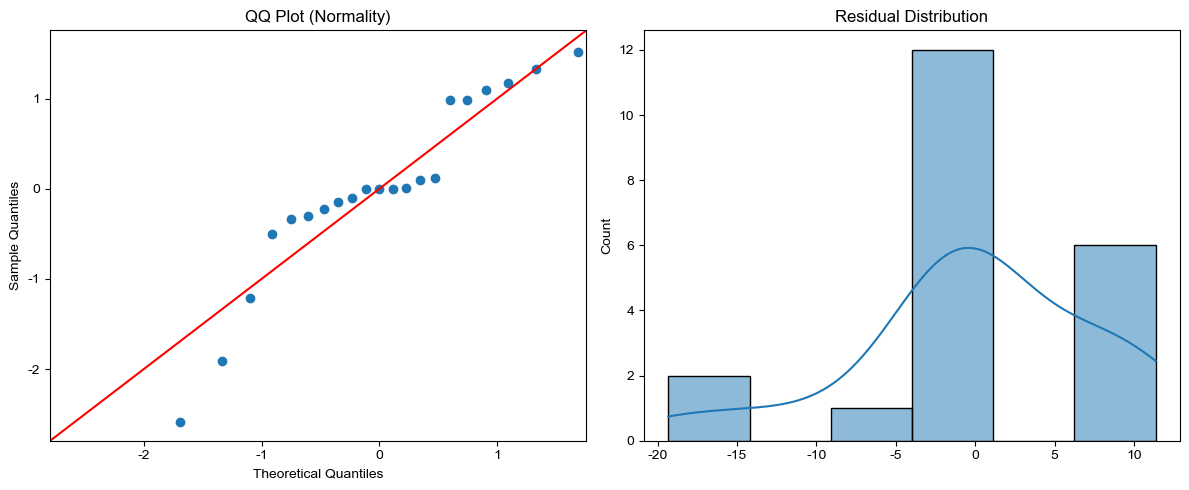

In [ ]:
residuals = model.resid

# 3.1 正态性 (Shapiro)
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk P值: {shapiro_test.pvalue:.4f} (p > 0.05 说明残差正态，通过)")

# 3.2 可视化诊断 (QQ图 + 残差分布)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sm.qqplot(residuals, line='45', fit=True, ax=ax[0])
ax[0].set_title("QQ Plot (Normality)")

sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

# 3. 执行 ANCOVA

## (1) 建立 ANCOVA 模型
- 主要模型: PSQI = 内容 + 使用时间 + 控制变量 + 误差
- 交互作用模型(可选): PSQI = 内容 + 使用时间 + 内容×时间 + 控制变量

## (2) ANCOVA 计算关键量

### ① 输入 (input)

- 每一行代表一个观测对象（一个学生）
  - 因变量 DV：连续分数（PSQI）//睡眠质量刺激强度
  - 自变量 UV：类别因子（content_type）//内容
  - 协变量 CV:（usage_time）
  - 可选控制变量（age, caffeine, gender, stress 等）
  
  | PSQI_total | usage_time | content_type | age | caffeine | stress | gender | 
  |------------|-----------|--------------|-----|---------|--------|----------| 
  | 7          | 120       | social       | 21  | 1       | 3      |   f  |
  | 5          | 45        | entertainment| 22  | 2       | 2      |   m  |
  | …          | …         | …            | …   | …       | …      |   m  |

> 1. **DV**  
>   - 这里是 `PSQI_total`  
>  - 类型：连续（interval/ratio）  
>  - 每个观测值的原始分数都必须提供  
>  - 例：一名学生的睡眠质量分数 7、另一名 5  

> 2. **IV**  
>    - **UV: 类别型因素（factor）**  
>      - 例：`content_type`（不同 App 类型）  
>      - 每个观测值对应一个类别  
>    - **CV: 连续型协变量（covariate）**  
>      - 例：`usage_time`（社交媒体使用分钟数）  
>      - 每个观测值的具体数值 

> 3. **可选控制变量（控制协变量）**  
>    - 例如 `age`, `caffeine`, `stress`  
>    - 类型：连续（最好是 interval）  
>    - 每个观测值对应具体数值  

### ② 计算
- 拟合线性模型，得到回归系数 β  
- 分解平方和（SS） → 计算 F  
- F + 自由度 → 查 F 分布 → p 值  
- SS_effect + SS_residual → Partial η²  

// 直接使用封装好的函数即可

In [ ]:
%%R

# Beipsiel_r

# 假设 data 是数据框
model <- aov(PSQI_total ~ usage_time * content_type + age + caffeine + stress, data=data)
summary(model)       # F,p (每个主效应和交互效应的 F 值 和对应的 p 值)
etaSquared(model)    # Partial η²

library(QuantPsyc)
lm.beta(model_lm)    # 输出标准化回归系数 β


### ③ 输出 (output)

- F 值
- p 值
- 效应量
  - Partial η²（经典 ANCOVA）
  - β（回归表达）

| 输出类型       | 怎么用           | 示例解读                                             |
| ---------- | ------------- | ------------------------------------------------ |
| F 值 + p 值  | 判断主效应或交互是否显著  | usage_time F=4.23, p=0.042 → 使用时间显著影响睡眠质量        |
| Partial η² | 量化效应大小        | usage_time η²=0.082 → 中等效果                       |
| β 系数（标准化）  | 解释每个自变量的标准化影响 | usage_time β=0.30 → 每增加 1 SD 使用时间，PSQI 增加 0.3 SD |

> **1.时间的主效应(H1)**
> 
> 在控制内容后, 使用时间是否显著预测睡眠质量? -> 看 F, p, Partial η² 或 β

> **2.内容的主效应(H2)**
> 
> 在控制使用时间后, 不同内容类型的睡眠质量是否不同? -> 看 F, p, Partial η²

> **3.交互效应(H3,可选)**
> 
> 不同内容下, 使用时间对睡眠质量的影响是否不同？

---
---

### ANCOVA 计算理论解释

---

#### 一、背景

ANCOVA 本质上是 **线性模型 + 方差分析** 的结合：

$$
Y_{ij} = \mu + \alpha_i + \beta X_{ij} + \varepsilon_{ij}
$$

- $Y_{ij}$：第 $i$ 组第 $j$ 个样本的因变量（PSQI）  
- $\alpha_i$：第 $i$ 组的组效应（content_type）  
- $\beta$：协变量（usage_time）的回归系数  
- $\varepsilon_{ij}$：误差项，假设 $\varepsilon \sim N(0,\sigma^2)$  

**核心思想**：去掉协变量引起的方差，再检验组效应。

---

#### 二、F 值的计算原理

##### 1. 分解平方和（Sum of Squares, SS）

ANCOVA 中常见几种平方和：

1. **SS_total**：总方差  

$$
SS_{\text{total}} = \sum_{i,j} (Y_{ij} - \bar{Y})^2
$$

2. **SS_effect**：某个因素（比如 content_type 或 usage_time）的方差贡献  

$$
SS_{\text{effect}} = \sum_{i,j} (\hat{Y}_{ij}^{(\text{effect})} - \bar{Y})^2
$$

3. **SS_residual**：残差方差（无法解释的部分）  

$$
SS_{\text{residual}} = SS_{\text{total}} - SS_{\text{effect}} - \text{其他因素的SS}
$$

> 注意：ANCOVA 会先用协变量 **调整因变量**，然后再计算组效应的平方和。

---

##### 2. 计算 F 值

F 值公式：

$$
F = \frac{MS_{\text{effect}}}{MS_{\text{residual}}} = \frac{SS_{\text{effect}}/df_{\text{effect}}}{SS_{\text{residual}}/df_{\text{residual}}}
$$

- $MS$ = Mean Square = 平均平方和  
- $df_{\text{effect}}$ = 自由度（组数-1 或 协变量自由度1）  
- $df_{\text{residual}}$ = 样本总数 - 模型参数数

**理解**：
- $F > 1$ → 因子解释的方差大于残差方差 → 有可能显著  
- $F \approx 1$ → 因子没解释额外方差 → 不显著

---

#### 三、p 值的理论含义

F 值对应的 p 值是：

$$
p = P(F_{df_1, df_2} \ge F_{\text{obs}})
$$

- $df_1 = df_{\text{effect}}$  
- $df_2 = df_{\text{residual}}$  

解释：

> 在零假设成立的情况下，观察到 $F \ge F_{\text{obs}}$ 的概率  
> - p 小 → 拒绝 H0（该因素有显著效应）  
> - p 大 → 不拒绝 H0

---

#### 四、Partial η²（效应量）

Partial η² 衡量某个因素**去掉其他因素影响后，解释了因变量多少比例的方差**。

公式：

$$
\eta^2_{\text{partial}} = \frac{SS_{\text{effect}}}{SS_{\text{effect}} + SS_{\text{residual}}}
$$

解释：

- 0.01 ≈ 小效应  
- 0.06 ≈ 中效应  
- 0.14 ≈ 大效应

> Partial η² 是经典 ANCOVA 中最常用的效应量。

---

#### 五、回归系数 β（标准化/非标准化）

##### 1. 非标准化 β

线性回归模型：

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \varepsilon
$$

- β1 = 每增加 1 个 $X_1$ 单位，$Y$ 平均增加 β1 个单位  
- 在 ANCOVA 中，协变量 β 表示**去掉组效应后的线性关系强度**

##### 2. 标准化 β

- 对 $X$ 和 $Y$ 做 z-score 标准化后得到的 β  
- 单位为 **标准差**，更容易比较不同变量的影响大小

---

#### 六、F 值、β 和 Partial η² 的关系

- **F 值** → 判断是否显著（统计显著性）  
- **Partial η²** → 判断效应大小（量化解释方差）  
- **β** → 量化自变量对因变量的线性影响（方向 + 标准化幅度）  

> F / Partial η² 对应 ANCOVA 的“方差分析视角”，β 对应“回归视角”，描述的是同一模型。

---

#### 七、计算流程总结（理论版）

1. **协变量调整**  
   - 先用协变量（usage_time 等）把因变量 $Y$ 调整  
   - $Y_{\text{adj}}$ = 去掉协变量线性贡献后的残差或修正均值

2. **计算平方和**  
   - $SS_{\text{effect}}$：组效应（或使用时间）解释的方差  
   - $SS_{\text{residual}}$：剩余方差  

3. **计算均方 / F 值**  
   - $MS_{\text{effect}} = SS_{\text{effect}} / df_{\text{effect}}$  
   - $MS_{\text{resid}} = SS_{\text{residual}} / df_{\text{residual}}$  
   - $F = MS_{\text{effect}} / MS_{\text{resid}}$  

4. **查 F 分布表 / p 值**  
   - 得到概率值，判断显著性  

5. **计算 Partial η²**  
   - $\eta^2_{\text{partial}} = SS_{\text{effect}} / (SS_{\text{effect}} + SS_{\text{residual}})$  

6. **查看回归系数 β**  
   - 线性模型中直接拟合得到  
   - 可标准化得到标准化 β

---

#### 八、总结

- **经典 ANCOVA** → F 值 + p 值 + Partial η²  
- **回归表达** → β 系数  
- 两者从不同角度描述同一个模型：  
  - F / Partial η² → 方差解释力  
  - β → 单位变化下的线性影响  
- 交互项 → 检验回归斜率是否同质（重要前提）  
- 控制变量 → 去掉潜在混杂影响


---
---

# 4. 总结分析

##  (1) Post-hoc Tests
- 如果内容类型显著, 使用 Bonferroni / Tukey
- 目的: 哪些内容组之间有差异？

## (2) 假设检验总结 (Beispiel)
|  假设   |   统计结果   |   结论   |
|  ----  | ----------- | ------- |
|  H1.1  | 时间 p < .05, .. | 拒绝 H₀ |
|  H1.2  | 内容 p < .05, .. | 拒绝 H₀ |
|  H1.3  | 交互 p > .05, ..| 保留 H₀ |


## (3)* 基于 [高/低刺激组] 的 ANCOVA

In [ ]:
median_val = data['stim_intensity'].median()
data['Arousal_Group'] = np.where(data['stim_intensity'] > median_val, 'High Arousal', 'Low Arousal')

print(f"刺激强度中位数: {median_val}")
print("分组完成。")

# 公式：用 Arousal_Group 替代具体的 Content
formula_macro = 'PSQI_total ~ usage_time * C(Arousal_Group) + age + caffeine + stress'
model_macro = smf.ols(formula_macro, data=data).fit()

print(model.summary())

刺激强度中位数: 6.0
分组完成。
                            OLS Regression Results                            
Dep. Variable:             PSQI_total   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1.158
Date:                Sun, 22 Feb 2026   Prob (F-statistic):              0.411
Time:                        13:11:32   Log-Likelihood:                -72.007
No. Observations:                  21   AIC:                             166.0
Df Residuals:                      10   BIC:                             177.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

<Figure size 800x600 with 0 Axes>

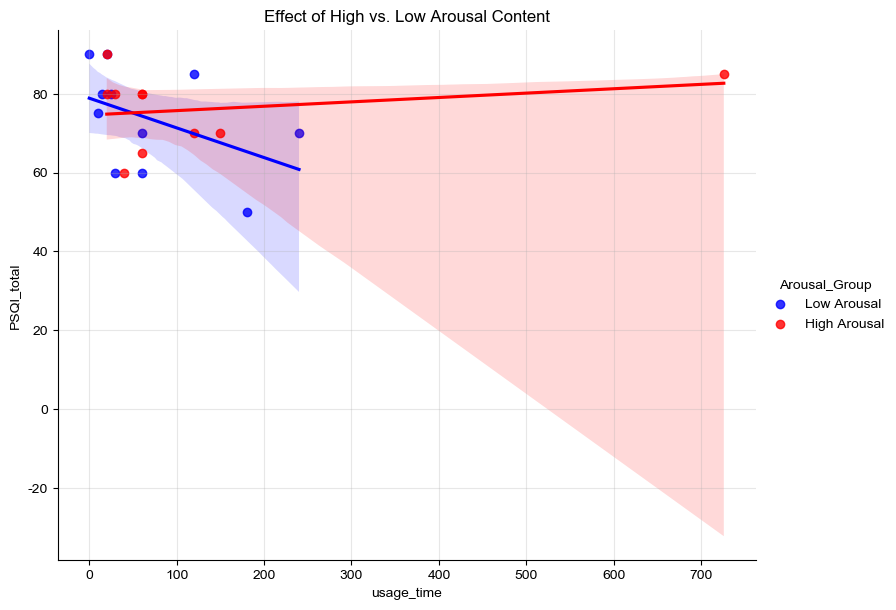

In [ ]:
plt.figure(figsize=(8, 6))
sns.lmplot(
    data=data, 
    x="usage_time", y="PSQI_total", 
    hue="Arousal_Group",  # High vs Low
    palette={'High Arousal': 'red', 'Low Arousal': 'blue'},
    height=6, aspect=1.3, ci=95
)
plt.title("Effect of High vs. Low Arousal Content")
plt.grid(True, alpha=0.3)
plt.show()